In [1]:
!pip install pandas numpy matplotlib scikit-learn openpyxl



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neural_network import MLPRegressor

print("installed succesfully")

installed succesfully


In [12]:
df = pd.read_excel("../data/streamflowData2.xlsx")
df.head()

,Date,streamflow (m3/s),Precipitation(mm)
0,1981-01-01,10.498646,26.301330
1,1981-02-01,6.543901,0.000000
2,1981-03-01,10.389399,4.681460
3,1981-04-01,6.926266,33.849901
4,1981-05-01,12.170126,98.444705


In [16]:
# Date parsing
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Column names from your dataset
q_col = "streamflow (m3/s)"
p_col = "Precipitation(mm)"

# Convert numeric
df[q_col] = pd.to_numeric(df[q_col], errors="coerce")
df[p_col] = pd.to_numeric(df[p_col], errors="coerce")

# Remove invalid rows
df = df.dropna(subset=["Date", q_col, p_col]).reset_index(drop=True)

Q = df[q_col].to_numpy(dtype=float)
P = df[p_col].to_numpy(dtype=float)
months = df["Date"].dt.month.to_numpy(dtype=int)


In [17]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


In [18]:
def time_train_test_split_indices(n, train_frac=0.7):
    split_idx = int(train_frac * n)
    return split_idx


In [19]:
def compute_monthwise_stats(values, months_arr):
    means = np.full(13, np.nan, dtype=float)
    sds = np.full(13, np.nan, dtype=float)

    for m in range(1, 13):
        v = values[months_arr == m]
        means[m] = np.nanmean(v)
        sds[m] = np.nanstd(v, ddof=1)

        if not np.isfinite(sds[m]) or sds[m] == 0:
            sds[m] = 1.0

    return means, sds


In [20]:
def monthwise_standardize(values, months_arr, means, sds):
    out = np.empty_like(values, dtype=float)
    for i in range(len(values)):
        m = months_arr[i]
        out[i] = (values[i] - means[m]) / sds[m]
    return out


def inverse_monthwise_standardize(values_std, months_arr, means, sds):
    out = np.empty_like(values_std, dtype=float)
    for i in range(len(values_std)):
        m = months_arr[i]
        out[i] = values_std[i] * sds[m] + means[m]
    return out


In [21]:
def make_lagged_multivariate_xy(Qs, Ps, n_lags):
    X, y = [], []

    for i in range(n_lags, len(Qs)):
        q_lags = Qs[i - n_lags:i][::-1]
        p_lags = Ps[i - n_lags:i][::-1]

        X.append(np.concatenate([q_lags, p_lags]))
        y.append(Qs[i])

    return np.array(X), np.array(y)


In [22]:
def make_target_months(months_arr, n_lags):
    return months_arr[n_lags:]


In [25]:
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPRegressor


results = []

best = {
    "Lag": None,
    "test_rmse": np.inf,
    "test_abs_r": -np.inf,
    "model": None,
    "train_obs": None,
    "train_pred": None,
    "test_obs": None,
    "test_pred": None,
}

for lag in range(1, 7):

    n_samples = len(Q) - lag
    if n_samples <= 20:
        continue

    split_idx = time_train_test_split_indices(n_samples, train_frac=0.7)
    train_target_idx = np.arange(lag, lag + split_idx)

    mQ_mean, mQ_sd = compute_monthwise_stats(Q[train_target_idx], months[train_target_idx])
    mP_mean, mP_sd = compute_monthwise_stats(P[train_target_idx], months[train_target_idx])

    Q_std = monthwise_standardize(Q, months, mQ_mean, mQ_sd)
    P_std = monthwise_standardize(P, months, mP_mean, mP_sd)

    X, y = make_lagged_multivariate_xy(Q_std, P_std, n_lags=lag)
    y_months = make_target_months(months, n_lags=lag)

    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]
    y_months_train, y_months_test = y_months[:split_idx], y_months[split_idx:]

    model = Pipeline(steps=[
        ("mlp", MLPRegressor(
            hidden_layer_sizes=(8,4),
            activation="relu",
            solver="adam",
            learning_rate_init=0.001,
            batch_size=32,
            alpha=0.2,
            max_iter=8000,
            tol=1e-6,
            n_iter_no_change=80,
            shuffle=False,
            random_state=42
        ))
    ])

    model.fit(X_train, y_train)

    yhat_train_std = model.predict(X_train)
    yhat_test_std = model.predict(X_test)

    y_train_orig = inverse_monthwise_standardize(y_train, y_months_train, mQ_mean, mQ_sd)
    yhat_train_orig = inverse_monthwise_standardize(yhat_train_std, y_months_train, mQ_mean, mQ_sd)

    y_test_orig = inverse_monthwise_standardize(y_test, y_months_test, mQ_mean, mQ_sd)
    yhat_test_orig = inverse_monthwise_standardize(yhat_test_std, y_months_test, mQ_mean, mQ_sd)

    train_rmse = rmse(y_train_orig, yhat_train_orig)
    train_r = np.corrcoef(y_train_orig, yhat_train_orig)[0,1]

    test_rmse = rmse(y_test_orig, yhat_test_orig)
    test_r = np.corrcoef(y_test_orig, yhat_test_orig)[0,1]

    results.append({
        "LagMonths": lag,
        "Train_R": train_r,
        "Train_RMSE": train_rmse,
        "Test_R": test_r,
        "Test_RMSE": test_rmse
    })

    test_abs_r = abs(test_r) if not np.isnan(test_r) else -np.inf

    if (test_rmse < best["test_rmse"]) or (
        np.isclose(test_rmse, best["test_rmse"], rtol=1e-4, atol=1e-6)
        and test_abs_r > best["test_abs_r"]
    ):
        best.update({
            "Lag": lag,
            "test_rmse": test_rmse,
            "test_abs_r": test_abs_r,
            "model": model,
            "train_obs": y_train_orig,
            "train_pred": yhat_train_orig,
            "test_obs": y_test_orig,
            "test_pred": yhat_test_orig
        })


In [26]:
res_df = pd.DataFrame(results)
pd.set_option("display.float_format", lambda x: f"{x:0.4f}")

print("\nComparison across lags:")
print(res_df.to_string(index=False))



Comparison across lags:
 LagMonths  Train_R  Train_RMSE  Test_R  Test_RMSE
         1   0.9029     47.5621  0.9014    62.2849
         2   0.9119     45.4898  0.9160    60.6417
         3   0.9419     37.3433  0.9202    56.0555
         4   0.9459     36.1635  0.8516    73.8488
         5   0.9679     28.0774  0.9223    59.2425
         6   0.9625     30.7499  0.8162    79.5768


In [27]:
best_train_r = np.corrcoef(best["train_obs"], best["train_pred"])[0,1]
best_train_rmse = rmse(best["train_obs"], best["train_pred"])

best_test_r = np.corrcoef(best["test_obs"], best["test_pred"])[0,1]
best_test_rmse = rmse(best["test_obs"], best["test_pred"])

print("\nBest Lag selection based on TEST RMSE:")
print(f"Best lag: {best['Lag']} month(s)")
print(f"Training -> R = {best_train_r:.4f}, RMSE = {best_train_rmse:.4f}")
print(f"Testing  -> R = {best_test_r:.4f}, RMSE = {best_test_rmse:.4f}")



Best Lag selection based on TEST RMSE:
Best lag: 3 month(s)
Training -> R = 0.9419, RMSE = 37.3433
Testing  -> R = 0.9202, RMSE = 56.0555


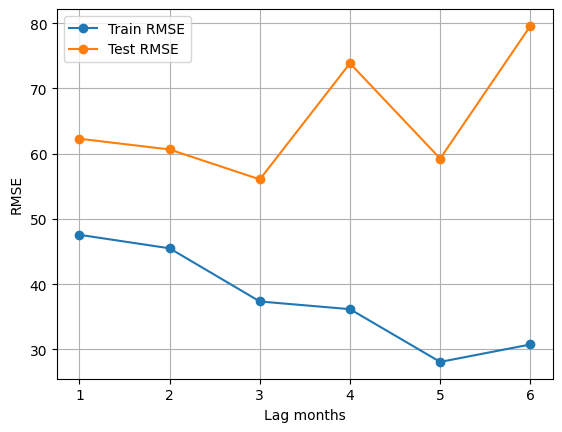

In [28]:
plt.figure()
plt.plot(res_df["LagMonths"], res_df["Train_RMSE"], marker='o', label="Train RMSE")
plt.plot(res_df["LagMonths"], res_df["Test_RMSE"], marker='o', label="Test RMSE")
plt.xlabel("Lag months")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)
plt.show()


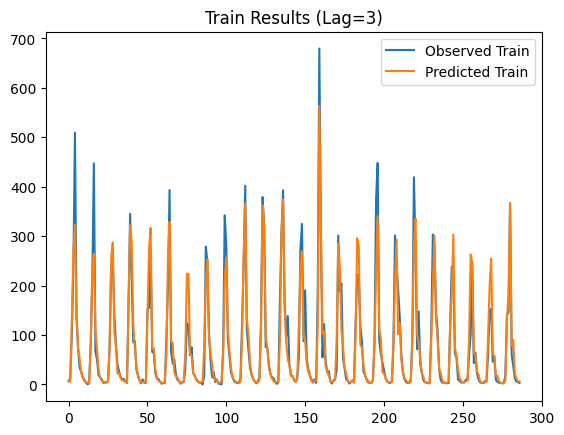

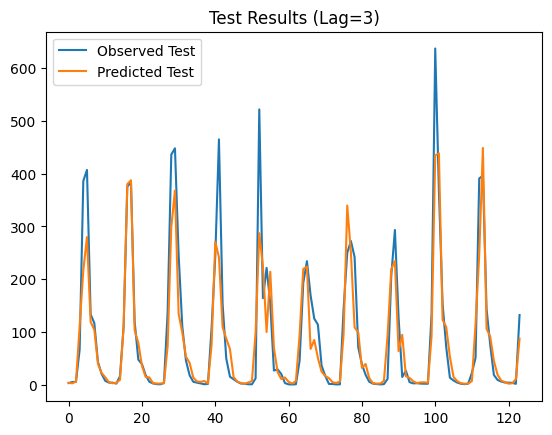

In [29]:
plt.figure()
plt.plot(best["train_obs"], label="Observed Train")
plt.plot(best["train_pred"], label="Predicted Train")
plt.legend()
plt.title(f"Train Results (Lag={best['Lag']})")
plt.show()

plt.figure()
plt.plot(best["test_obs"], label="Observed Test")
plt.plot(best["test_pred"], label="Predicted Test")
plt.legend()
plt.title(f"Test Results (Lag={best['Lag']})")
plt.show()
